## 01. Importing libraries and adjusting settings

In [2]:
# importing the core libraries and adjusting the settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import display
import holidays
import requests

# setting style for visualizations
sns.set_theme(style="darkgrid")

# limiting scientific notation
pd.set_option("display.float_format", "{:.2f}".format)

## 02. German Federal States Extraction - reverse engineering

#### **Extracting Lands Based on Similarity Matrices**

In [2]:
# In this step, the locations of individual stores (German Lands) were retrieved based on the public and school holidays calendar.

# This was possible because the holiday calendar in Germany varies across different regions.

# Similarity matrices were used for this step. The results were compared with those of other data enthusiasts available online - and they were consistent.

In [3]:
# loading & merging original data 

df_store = pd.read_csv("../01_data/01_raw/01_Rossmann/store.csv")
df_train = pd.read_csv("../01_data/01_raw/01_Rossmann/train.csv")
df_hol = pd.merge(df_train, df_store, on = "Store", how = "left")
df_hol.head()

/var/folders/mq/ckpznt291nn2xj9_5lp2btvw0000gn/T/ipykernel_10907/226497282.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("../01_data/01_raw/01_Rossmann/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


In [4]:
# pivot table for SchoolHoliday

pivot_schoolholidays = df_hol.pivot_table(index="Store",
                                          columns="Date",
                                          values="SchoolHoliday",
                                          aggfunc = "mean")
pivot_schoolholidays

Date,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06,2013-01-07,2013-01-08,2013-01-09,2013-01-10,...,2015-07-22,2015-07-23,2015-07-24,2015-07-25,2015-07-26,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31
Store,,,,,,,,,,,,,,,,,,,,,
1,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
2,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
3,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
4,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
5,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
1112,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
1113,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00


In [5]:
# adjusting the date type of pivot table columns
pivot_schoolholidays.columns = pd.to_datetime(pivot_schoolholidays.columns)

# mask for weekends
weekend_mask = pivot_schoolholidays.columns.weekday >= 5  # 5=Saturday, 6=Sunday

# schools are closed on weekends
pivot_schoolholidays.loc[:, weekend_mask] = 1

In [6]:
df_hol["StateHoliday_flag"] = df_hol["StateHoliday"].apply(lambda x: 0 if str(x) == "0" else 1)


# pivot table for StateHoliday

pivot_stateholidays = df_hol.pivot_table(index="Store",
                                         columns="Date",
                                         values="StateHoliday_flag",
                                         aggfunc="mean").fillna(1)
pivot_stateholidays

Date,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06,2013-01-07,2013-01-08,2013-01-09,2013-01-10,...,2015-07-22,2015-07-23,2015-07-24,2015-07-25,2015-07-26,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31
Store,,,,,,,,,,,,,,,,,,,,,
1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1112,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1113,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [7]:
# if StateHoliday == 1, then we want to have value 1 in our main dataframe

pivot_schoolholidays[pivot_stateholidays == 1] = 1

In [8]:
# sanity check
print(pivot_schoolholidays.max().max())  # should be equal to 1
print(pivot_schoolholidays.min().min())  # should be equal to 0

1.0
0.0


In [9]:
import glob
import ast
import pathlib

# loading holiday calendars for every German land
path = "../01_data/01_raw/02_external/data-holidays"

# ID for the federal states - e.g., BE - Berlin
short_names = ["BB","BE","BW","BY","HB","HE","HH","MV","NI","NW","RP","SH","SL","SN","ST","TH"]

date_range = pd.date_range("2013-01-01", "2015-07-31")

# function to extract and process information
def parse_subdivisions(val):
    if pd.isna(val):
        return None
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
    except:
        pass
    return [val]

rows = []

files = glob.glob(f"{path}/holidays*.csv")

for file in files:
    df = pd.read_csv(file, sep=";")
    df.columns = df.columns.str.strip().str.lower()

    for _, r in df.iterrows():

        # only school holidays
        if r["type"] != "School":
            continue

        start = pd.to_datetime(r["startdate"], errors="coerce")
        end = pd.to_datetime(r["enddate"], errors="coerce")

        # if we don't have "end" filled in the original data → we assign 1 day
        if pd.isna(end):
            end = start

        if pd.isna(start):
            continue

        # skipping values out of range of interest 
        if end < date_range.min() or start > date_range.max():
            continue

        days = pd.date_range(
            max(start, date_range.min()),
            min(end, date_range.max())
        )

        if "subdivisions" in df.columns:
            subdivisions = parse_subdivisions(r.get("subdivisions"))
        else:
            subdivisions = None

        # if lack of region → all lands
        if not subdivisions:
            subdivisions = short_names

        for land in subdivisions:
            for d in days:
                rows.append((land, d, 1))


# long format of the data
df_long = pd.DataFrame(rows, columns=["land", "date", "holiday"])


# deleting duplicates (eg. overlap of files)
df_long = df_long.drop_duplicates(["land", "date"])


# final pivot
final_pivot = df_long.pivot_table(index="land",
                               columns="date",
                               values="holiday",
                               aggfunc="max",
                               fill_value=0)

final_pivot = final_pivot.reindex(index=short_names, columns=date_range, fill_value=0)

final_pivot = final_pivot.sort_index(axis=1)

print(final_pivot.shape)

(16, 942)


In [10]:
pd.set_option("display.max_columns", None)
final_pivot

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06,2013-01-07,2013-01-08,2013-01-09,2013-01-10,2013-01-11,2013-01-12,2013-01-13,2013-01-14,2013-01-15,2013-01-16,2013-01-17,2013-01-18,2013-01-19,2013-01-20,2013-01-21,2013-01-22,2013-01-23,2013-01-24,2013-01-25,2013-01-26,2013-01-27,2013-01-28,2013-01-29,2013-01-30,2013-01-31,2013-02-01,2013-02-02,2013-02-03,2013-02-04,2013-02-05,2013-02-06,2013-02-07,2013-02-08,2013-02-09,2013-02-10,2013-02-11,2013-02-12,2013-02-13,2013-02-14,2013-02-15,2013-02-16,2013-02-17,2013-02-18,2013-02-19,2013-02-20,2013-02-21,2013-02-22,2013-02-23,2013-02-24,2013-02-25,2013-02-26,2013-02-27,2013-02-28,2013-03-01,2013-03-02,2013-03-03,2013-03-04,2013-03-05,2013-03-06,2013-03-07,2013-03-08,2013-03-09,2013-03-10,2013-03-11,2013-03-12,2013-03-13,2013-03-14,2013-03-15,2013-03-16,2013-03-17,2013-03-18,2013-03-19,2013-03-20,2013-03-21,2013-03-22,2013-03-23,2013-03-24,2013-03-25,2013-03-26,2013-03-27,2013-03-28,2013-03-29,2013-03-30,2013-03-31,2013-04-01,2013-04-02,2013-04-03,2013-04-04,2013-04-05,2013-04-06,2013-04-07,2013-04-08,2013-04-09,2013-04-10,2013-04-11,2013-04-12,2013-04-13,2013-04-14,2013-04-15,2013-04-16,2013-04-17,2013-04-18,2013-04-19,2013-04-20,2013-04-21,2013-04-22,2013-04-23,2013-04-24,2013-04-25,2013-04-26,2013-04-27,2013-04-28,2013-04-29,2013-04-30,2013-05-01,2013-05-02,2013-05-03,2013-05-04,2013-05-05,2013-05-06,2013-05-07,2013-05-08,2013-05-09,2013-05-10,2013-05-11,2013-05-12,2013-05-13,2013-05-14,2013-05-15,2013-05-16,2013-05-17,2013-05-18,2013-05-19,2013-05-20,2013-05-21,2013-05-22,2013-05-23,2013-05-24,2013-05-25,2013-05-26,2013-05-27,2013-05-28,2013-05-29,2013-05-30,2013-05-31,2013-06-01,2013-06-02,2013-06-03,2013-06-04,2013-06-05,2013-06-06,2013-06-07,2013-06-08,2013-06-09,2013-06-10,2013-06-11,2013-06-12,2013-06-13,2013-06-14,2013-06-15,2013-06-16,2013-06-17,2013-06-18,2013-06-19,2013-06-20,2013-06-21,2013-06-22,2013-06-23,2013-06-24,2013-06-25,2013-06-26,2013-06-27,2013-06-28,2013-06-29,2013-06-30,2013-07-01,2013-07-02,2013-07-03,2013-07-04,2013-07-05,2013-07-06,2013-07-07,2013-07-08,2013-07-09,2013-07-10,2013-07-11,2013-07-12,2013-07-13,2013-07-14,2013-07-15,2013-07-16,2013-07-17,2013-07-18,2013-07-19,2013-07-20,2013-07-21,2013-07-22,2013-07-23,2013-07-24,2013-07-25,2013-07-26,2013-07-27,2013-07-28,2013-07-29,2013-07-30,2013-07-31,2013-08-01,2013-08-02,2013-08-03,2013-08-04,2013-08-05,2013-08-06,2013-08-07,2013-08-08,2013-08-09,2013-08-10,2013-08-11,2013-08-12,2013-08-13,2013-08-14,2013-08-15,2013-08-16,2013-08-17,2013-08-18,2013-08-19,2013-08-20,2013-08-21,2013-08-22,2013-08-23,2013-08-24,2013-08-25,2013-08-26,2013-08-27,2013-08-28,2013-08-29,2013-08-30,2013-08-31,2013-09-01,2013-09-02,2013-09-03,2013-09-04,2013-09-05,2013-09-06,2013-09-07,2013-09-08,2013-09-09,2013-09-10,2013-09-11,2013-09-12,2013-09-13,2013-09-14,2013-09-15,2013-09-16,2013-09-17,2013-09-18,2013-09-19,2013-09-20,2013-09-21,2013-09-22,2013-09-23,2013-09-24,2013-09-25,2013-09-26,2013-09-27,2013-09-28,2013-09-29,2013-09-30,2013-10-01,2013-10-02,2013-10-03,2013-10-04,2013-10-05,2013-10-06,2013-10-07,2013-10-08,2013-10-09,2013-10-10,2013-10-11,2013-10-12,2013-10-13,2013-10-14,2013-10-15,2013-10-16,2013-10-17,2013-10-18,2013-10-19,2013-10-20,2013-10-21,2013-10-22,2013-10-23,2013-10-24,2013-10-25,2013-10-26,2013-10-27,2013-10-28,2013-10-29,2013-10-30,2013-10-31,2013-11-01,2013-11-02,2013-11-03,2013-11-04,2013-11-05,2013-11-06,2013-11-07,2013-11-08,2013-11-09,2013-11-10,2013-11-11,2013-11-12,2013-11-13,2013-11-14,2013-11-15,2013-11-16,2013-11-17,2013-11-18,2013-11-19,2013-11-20,2013-11-21,2013-11-22,2013-11-23,2013-11-24,2013-11-25,2013-11-26,2013-11-27,2013-11-28,2013-11-29,2013-11-30,2013-12-01,2013-12-02,2013-12-03,2013-12-04,2013-12-05,2013-12-06,2013-12-07,2013-12-08,2013-12-09,2013-12-10,2013-12-11,2013-12-12,2013-12-13,2013-12-14,2013-12-15,2013-12-16,2013-12-17,2013-12-18,2013-12-19,2013-12-20,2013-12-21,2013-12-22,2013-12-23,2013-12-24,2013-12-25,2013-12-26,2013-12-27,2013-12-28,2013-12-29,2013-1

In [11]:
pivot_schoolholidays.shape[1] == final_pivot.shape[1] # sanity check

True

In [12]:
store_matrix = pivot_schoolholidays.values   # (1115, T)
land_matrix = final_pivot.values                # (16, T)

# similarity matrix - original holidays calendar vs our reverse engineered one

similarity_matrix = np.zeros((store_matrix.shape[0], land_matrix.shape[0]))

for i in range(store_matrix.shape[0]):
    for j in range(land_matrix.shape[0]):
        # similarity_matrix[i, j] = np.sum(store_matrix[i] == land_matrix[j]) / store_matrix.shape[1] # includes days without holiday periods
        similarity_matrix[i, j] = np.sum((store_matrix[i] == 1) & (land_matrix[j] == 1)) / np.sum(land_matrix[j] == 1) # includes only days that are holidays


similarity_df = pd.DataFrame(
    similarity_matrix,
    index=pivot_schoolholidays.index,
    columns=final_pivot.index
)   
similarity_df

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH
Store,,,,,,,,,,,,,,,,
1,0.67,0.67,0.66,0.63,0.66,0.78,0.56,0.70,0.66,0.65,0.73,0.65,0.73,0.68,0.69,0.65
2,0.67,0.66,0.64,0.61,0.63,0.68,0.59,0.68,0.63,0.70,0.67,0.68,0.69,0.72,0.69,0.78
3,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70
4,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73
5,0.71,0.71,0.68,0.67,0.67,0.73,0.58,0.73,0.67,0.70,0.72,0.66,0.75,0.80,0.74,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70
1112,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70
1113,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70


In [13]:
# assigning lands based on similarity scores 

land_cols = final_pivot.index

similarity_df["assigned_land"] = similarity_df[land_cols].idxmax(axis=1)
similarity_df["score"] = similarity_df[land_cols].max(axis=1)

sorted_vals = np.sort(similarity_df[final_pivot.index].values, axis=1)
similarity_df["confidence"] = sorted_vals[:, -1] - sorted_vals[:, -2]

similarity_df

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,
1,0.67,0.67,0.66,0.63,0.66,0.78,0.56,0.70,0.66,0.65,0.73,0.65,0.73,0.68,0.69,0.65,HE,0.78,0.04
2,0.67,0.66,0.64,0.61,0.63,0.68,0.59,0.68,0.63,0.70,0.67,0.68,0.69,0.72,0.69,0.78,TH,0.78,0.06
3,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08
4,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
5,0.71,0.71,0.68,0.67,0.67,0.73,0.58,0.73,0.67,0.70,0.72,0.66,0.75,0.80,0.74,0.74,SN,0.80,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08
1112,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08
1113,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01


In [14]:
similarity_df[similarity_df["confidence"] == 0.0] 

# we have an identical score for some observations (HB & NI) 
# HB (Bremen) is an enclave for NI (Lower Saxony), so the calendar of holidays may be very similar (or the same) - we can combine them into one region later

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,
10,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
70,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
107,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
112,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
268,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
304,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
379,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
504,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
511,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00


In [15]:
similarity_df[similarity_df["assigned_land"] == "NI"] 

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,


In [16]:
similarity_df.describe()

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,score,confidence
count,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00,1115.00
mean,0.66,0.66,0.65,0.63,0.62,0.67,0.57,0.68,0.62,0.67,0.67,0.65,0.67,0.66,0.66,0.66,0.76,0.04
std,0.12,0.12,0.04,0.03,0.10,0.09,0.10,0.11,0.10,0.09,0.09,0.11,0.07,0.08,0.09,0.09,0.08,0.03
min,0.46,0.46,0.54,0.53,0.45,0.49,0.41,0.47,0.45,0.52,0.49,0.46,0.53,0.51,0.49,0.49,0.60,0.00
25%,0.66,0.66,0.65,0.62,0.60,0.62,0.56,0.67,0.60,0.60,0.63,0.65,0.63,0.60,0.62,0.59,0.77,0.02
50%,0.67,0.66,0.65,0.62,0.61,0.67,0.57,0.68,0.61,0.69,0.66,0.67,0.68,0.68,0.68,0.70,0.79,0.04
75%,0.71,0.71,0.68,0.65,0.69,0.73,0.60,0.73,0.69,0.79,0.73,0.68,0.72,0.68,0.69,0.70,0.80,0.08
max,0.89,0.90,0.72,0.69,0.80,0.78,0.77,0.88,0.80,0.79,0.80,0.82,0.76,0.80,0.81,0.78,0.90,0.08


In [17]:
similarity_df.head(10)

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,
1,0.67,0.67,0.66,0.63,0.66,0.78,0.56,0.70,0.66,0.65,0.73,0.65,0.73,0.68,0.69,0.65,HE,0.78,0.04
2,0.67,0.66,0.64,0.61,0.63,0.68,0.59,0.68,0.63,0.70,0.67,0.68,0.69,0.72,0.69,0.78,TH,0.78,0.06
3,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08
4,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
5,0.71,0.71,0.68,0.67,0.67,0.73,0.58,0.73,0.67,0.70,0.72,0.66,0.75,0.80,0.74,0.74,SN,0.80,0.05
6,0.71,0.71,0.68,0.67,0.67,0.73,0.58,0.73,0.67,0.70,0.72,0.66,0.75,0.80,0.74,0.74,SN,0.80,0.05
7,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
8,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
9,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08


In [18]:
similarity_df[similarity_df["confidence"] < 0.005] 

# we also have very similar scores for BE (Berlin) and BB (Brandenburg) 
# BE (Berlin) is an enclave for BB (Brandenburg), so here also the calendar of holidays may be very similar - we can also combine them into one region later

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,
4,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
10,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
34,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
44,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
70,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
1081,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00
1085,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00


In [19]:
similarity_df[similarity_df["assigned_land"] == "BB"] 

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,


In [20]:
similarity_df[(similarity_df["confidence"] > 0.005) & (similarity_df["confidence"] <= 0.015)] 

# relatively high level of similarity is also noticed for two northern regions of Germany - MV (Mecklenburg-Western Pomerania) and SH (Schleswig-Holstein)
# here we can also combine them into one region later

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,
7,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
8,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
11,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
12,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
15,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
1099,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01
1101,0.78,0.77,0.65,0.62,0.71,0.71,0.69,0.80,0.71,0.69,0.74,0.81,0.70,0.68,0.68,0.70,SH,0.81,0.01


In [21]:
similarity_df[similarity_df["assigned_land"] == "MV"] 

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,


In [22]:
similarity_df[similarity_df["assigned_land"] == "SL"] 

# we probably don't have observations for Saarland (small western land) in our data - this region has no strong similarities to others

land,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence
Store,,,,,,,,,,,,,,,,,,,


In [23]:
similarity_df.groupby("assigned_land")["score"].agg(["min", "max", "mean"])

,min,max,mean
assigned_land,,,
BE,0.90,0.90,0.90
BW,0.72,0.72,0.72
BY,0.60,0.60,0.60
HB,0.80,0.80,0.80
HE,0.78,0.78,0.78
HH,0.77,0.77,0.77
NW,0.79,0.79,0.79
RP,0.77,0.77,0.77
SH,0.81,0.81,0.81


#### **Comparing own results with those publicly available**

In [24]:
# loading extraction results available on the Kaggle forum

states_ext = pd.read_csv("../01_data/01_raw/02_external/store_states.csv")
states_ext.head()

,Store,State
0,1,HE
1,2,TH
2,3,NW
3,4,BE
4,5,SN


In [25]:
# merging dataframes

similarity_df = similarity_df.merge(states_ext, on="Store", how="left")
similarity_df.head()

,Store,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence,State
0,1,0.67,0.67,0.66,0.63,0.66,0.78,0.56,0.70,0.66,0.65,0.73,0.65,0.73,0.68,0.69,0.65,HE,0.78,0.04,HE
1,2,0.67,0.66,0.64,0.61,0.63,0.68,0.59,0.68,0.63,0.70,0.67,0.68,0.69,0.72,0.69,0.78,TH,0.78,0.06,TH
2,3,0.66,0.66,0.65,0.62,0.60,0.67,0.57,0.68,0.60,0.79,0.66,0.67,0.68,0.68,0.68,0.70,NW,0.79,0.08,NW
3,4,0.89,0.90,0.71,0.68,0.78,0.77,0.74,0.88,0.78,0.73,0.80,0.82,0.76,0.75,0.75,0.73,BE,0.90,0.00,BE
4,5,0.71,0.71,0.68,0.67,0.67,0.73,0.58,0.73,0.67,0.70,0.72,0.66,0.75,0.80,0.74,0.74,SN,0.80,0.05,SN


In [26]:
# checking the differences

similarity_df[similarity_df["assigned_land"] != similarity_df["State"]]

,Store,BB,BE,BW,BY,HB,HE,HH,MV,NI,NW,RP,SH,SL,SN,ST,TH,assigned_land,score,confidence,State
9,10,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
69,70,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
106,107,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
111,112,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
267,268,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
303,304,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
378,379,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
503,504,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
510,511,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"
561,562,0.71,0.71,0.65,0.62,0.80,0.69,0.61,0.73,0.80,0.61,0.74,0.68,0.68,0.65,0.68,0.63,HB,0.80,0.00,"HB,NI"


In [27]:
# okay, we see that the differences actually come down to those observations that also had identical scores in our analysis (HB and NI, where "confidence" == 0),
# meaning that holiday calendars are the same for these lands.

# we can assume that our results are consistent with those publicly available - that's a good signal.

#### **Adjusting Land Assignment**

In [28]:
# let's combine the federal states that had a similar confidence score

# BE/BB -> BE (Berlin) + BB (Brandenburgia)
# HB/NI -> HB (Bremen) + NI (Lower Saxony)
# SH/MV -> SH (Schleswig-Holstein) + MV (Mecklenburg-Western Pomerania)

# (SL -> there were no observations)

In [29]:
cols_assignment = ["Store", "assigned_land"]
land_assignment = similarity_df[cols_assignment]
land_assignment.head()

,Store,assigned_land
0,1,HE
1,2,TH
2,3,NW
3,4,BE
4,5,SN


In [30]:
land_assignment["assigned_land"] = land_assignment["assigned_land"].replace({"BE": "BE/BB", # Berlin + Brandenburgia
                                                                             "HB": "HB/NI", # Bremen + Lower Saxony
                                                                             "SH": "SH/MV"}) # Schleswig-Holstein + Mecklenburg-Western Pomerania
land_assignment.head()

,Store,assigned_land
0,1,HE
1,2,TH
2,3,NW
3,4,BE/BB
4,5,SN


In [31]:
land_assignment.groupby("assigned_land").count()

,Store
assigned_land,
BE/BB,92
BW,73
BY,180
HB/NI,22
HE,112
HH,28
NW,286
RP,40
SH/MV,115


In [32]:
# land_assignment.to_csv("state_per_store_assignment.csv", index = False)

### **German Land Extraction - summary**

- Since the original dataset does not explicitly provide store locations, an attempt was made to `approximate them by leveraging differences in school holiday calendar patterns` across different German federal states. In Germany, school holiday schedules vary significantly between different regions.

- For each store, a `time series of school holiday indicator was compared with offical regional holiday calendars`. A similarity score was computed to match each store to the most likely federal state. For `some cases` (enclaves or neighboring states in the north) the differences in calendar `similarity were very small, so they were combined` to reduce uncertainty. 

- During the analysis, a different approach to extracting German was found on Kaggle. Despite methodological differences, the resulting assignments `were consistent` with these received in own approach, which increases confidence in the results.

- It should be noted, however, that this mapping is `an approximation and may not be perfectly accurate for all stores`. Nevertheless, it provides a `reasonable proxy for store location` and allowed for testing region-level external features (e.g., describing weather conditions) in the analysis. 


## 03. Features Describing Weather Conditions - External Data

In [33]:
# thanks to the information on store locations obtained in the previous step, it was decided to include weather-related variables 
# (temperature, precipitation) in the analysis and check whether they could have had a significant impact on sales during the analyzed period

# weather data was extractd by using the Open-Meteo API - information was taken for individual capitals of the states

In [34]:
# MAPPING: STATE -> CITY

# all German federal states: 'BB', 'BE', 'BW', 'BY', 'HB', 'HE', 'HH', 'MV', 'NI', 'NW', 'RP', 'SH','SL', 'SN', 'ST', 'TH'

capitals = {
    "BB": ("Potsdam", 52.3933, 13.0657), # Brandenburg
    "BE": ("Berlin", 52.3107, 13.2433), # Berlin
    "BW": ("Stuttgart", 48.7758, 9.1829), # Baden-Württemberg
    "BY": ("Munich", 48.1351, 11.5820), # Bavaria
    "HB": ("Bremen", 53.0793, 8.8017), # Bremen
    "HE": ("Wiesbaden", 50.0782, 8.2398), # Hesse
    "HH": ("Hamburg", 53.5511, 9.9937), # Hamburg
    "MV": ("Schwerin", 53.6294, 11.4148), # Mecklenburg-Vorpommern
    "NI": ("Hanover", 52.3759, 9.7320), # Lower Saxony
    "NW": ("Düsseldorf", 51.2277, 6.7735), # North Rhine-Westphalia
    "RP": ("Mainz", 49.9929, 8.2473), # Rhineland-Palatinate
    "SH": ("Kiel", 54.1854, 9.8220), # Schleswig-Holstein
    "SL": ("Saarbrücken", 49.2402, 6.9969), # Saarland
    "SN": ("Dresden", 51.0504, 13.7373), # Saxony
    "ST": ("Magdeburg", 52.1205, 11.6276), # Saxony-Anhalt
    "TH": ("Erfurt", 50.9848, 11.0299) # Thuringia
}

In [35]:
### FUNCTION TO EXTRACT WEATHER DATA ### 

def get_weather(lat, lon):
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        "&start_date=2013-01-01&end_date=2015-09-17"
        "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean"
        "&hourly=precipitation"
        "&timezone=Europe/Berlin"
    )

    res = requests.get(url).json()

    # DAILY TEMPERATURE (max, min, mean)
    df_daily = pd.DataFrame(res["daily"])
    df_daily["date"] = pd.to_datetime(df_daily["time"])
    df_daily = df_daily.drop(columns=["time"])

    # HOURLY PRECIPITATION SUM (rainfall as a factor that might discourage people from going shopping)
    df_hourly = pd.DataFrame(res["hourly"])
    df_hourly["time"] = pd.to_datetime(df_hourly["time"])
    df_hourly["date"] = df_hourly["time"].dt.date
    df_hourly["hour"] = df_hourly["time"].dt.hour


    # we filter data only for 8:00AM (included) - 9:00PM (exluded) - as a proxy of Rossmann stores opening hours (13 in total)
    df_hourly = df_hourly[
        (df_hourly["hour"] >= 8) & (df_hourly["hour"] < 21)
    ]

    # aggregation & adding a variable for number of hours of precipitation
    df_precip = df_hourly.groupby("date").agg(
        precipitation_sum=("precipitation", "sum"),
        precipitation_hours=("precipitation", lambda x: (x > 0).sum())
    ).reset_index()

    df_precip["date"] = pd.to_datetime(df_precip["date"])

    # merging results
    df = df_daily.merge(df_precip, on="date", how="left")

    # filling NaN for days without precipitation
    df["precipitation_sum"] = df["precipitation_sum"].fillna(0)
    df["precipitation_hours"] = df["precipitation_hours"].fillna(0)

    return df

In [36]:
all_weather = []

for land, (city, lat, lon) in capitals.items():
    df = get_weather(lat, lon)
    df["land"] = land
    df["city"] = city
    all_weather.append(df)

weather_df = pd.concat(all_weather)

In [37]:
weather_df.describe()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,date,precipitation_sum,precipitation_hours
count,15840.00,15840.00,15840.00,15840,15840.00,15840.00
mean,14.25,7.04,10.61,2014-05-10 12:00:00,1.14,2.30
min,-7.80,-17.70,-12.20,2013-01-01 00:00:00,0.00,0.00
25%,7.70,1.80,4.70,2013-09-05 00:00:00,0.00,0.00
50%,14.90,7.50,11.20,2014-05-10 12:00:00,0.00,0.00
75%,20.10,12.30,16.10,2015-01-13 00:00:00,1.10,4.00
max,37.50,23.60,30.00,2015-09-17 00:00:00,35.20,13.00
std,8.07,6.67,7.27,NaN,2.48,3.36


In [38]:
weather_df.info()

<class 'pandas.DataFrame'>
Index: 15840 entries, 0 to 989
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   temperature_2m_max   15840 non-null  float64       
 1   temperature_2m_min   15840 non-null  float64       
 2   temperature_2m_mean  15840 non-null  float64       
 3   date                 15840 non-null  datetime64[us]
 4   precipitation_sum    15840 non-null  float64       
 5   precipitation_hours  15840 non-null  int64         
 6   land                 15840 non-null  str           
 7   city                 15840 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(2)
memory usage: 1.1 MB


In [39]:
cols_order = ["date", "land", "city", "temperature_2m_max", "temperature_2m_min",
              "temperature_2m_mean", "precipitation_sum", "precipitation_hours"]
weather_df = weather_df[cols_order]
weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df = weather_df.sort_values("date").reset_index()
weather_df.drop(columns=["index"], inplace=True)
weather_df.head(16)

,date,land,city,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours
0,2013-01-01,BB,Potsdam,7.50,6.00,6.60,1.10,4
1,2013-01-01,SH,Kiel,8.60,3.50,6.60,1.90,6
2,2013-01-01,SL,Saarbrücken,7.20,2.30,5.70,6.10,10
3,2013-01-01,SN,Dresden,7.60,3.90,5.50,0.00,0
4,2013-01-01,ST,Magdeburg,7.10,5.30,6.60,1.20,5
5,2013-01-01,BY,Munich,5.80,-3.10,1.00,0.00,0
6,2013-01-01,HB,Bremen,9.50,3.40,6.90,6.80,10
7,2013-01-01,RP,Mainz,7.40,3.80,6.00,2.60,9
8,2013-01-01,HH,Hamburg,9.30,3.50,7.00,6.40,11
9,2013-01-01,MV,Schwerin,8.90,4.10,6.90,6.10,12


In [40]:
# adjusting for merged lands

weather_df["land"] = weather_df["land"].replace({
    "BE": "BE/BB",
    "BB": "BE/BB",
    "HB": "HB/NI",
    "NI": "HB/NI",
    "SH": "SH/MV",
    "MV": "SH/MV"
})

weather_df = (
    weather_df
    .groupby(["date", "land"], as_index=False)
    .agg({
        "temperature_2m_max": "mean",
        "temperature_2m_min": "mean",
        "temperature_2m_mean": "mean",
        "precipitation_sum": "mean",
        "precipitation_hours": "mean"
    })
)

weather_df.head(16)

,date,land,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours
0,2013-01-01,BE/BB,7.45,5.90,6.55,0.70,3.00
1,2013-01-01,BW,7.80,3.40,5.70,1.30,6.00
2,2013-01-01,BY,5.80,-3.10,1.00,0.00,0.00
3,2013-01-01,HB/NI,9.40,3.65,6.90,6.25,11.00
4,2013-01-01,HE,7.70,4.10,6.20,2.60,9.00
5,2013-01-01,HH,9.30,3.50,7.00,6.40,11.00
6,2013-01-01,NW,9.40,3.00,6.70,7.00,9.00
7,2013-01-01,RP,7.40,3.80,6.00,2.60,9.00
8,2013-01-01,SH/MV,8.75,3.80,6.75,4.00,9.00
9,2013-01-01,SL,7.20,2.30,5.70,6.10,10.00


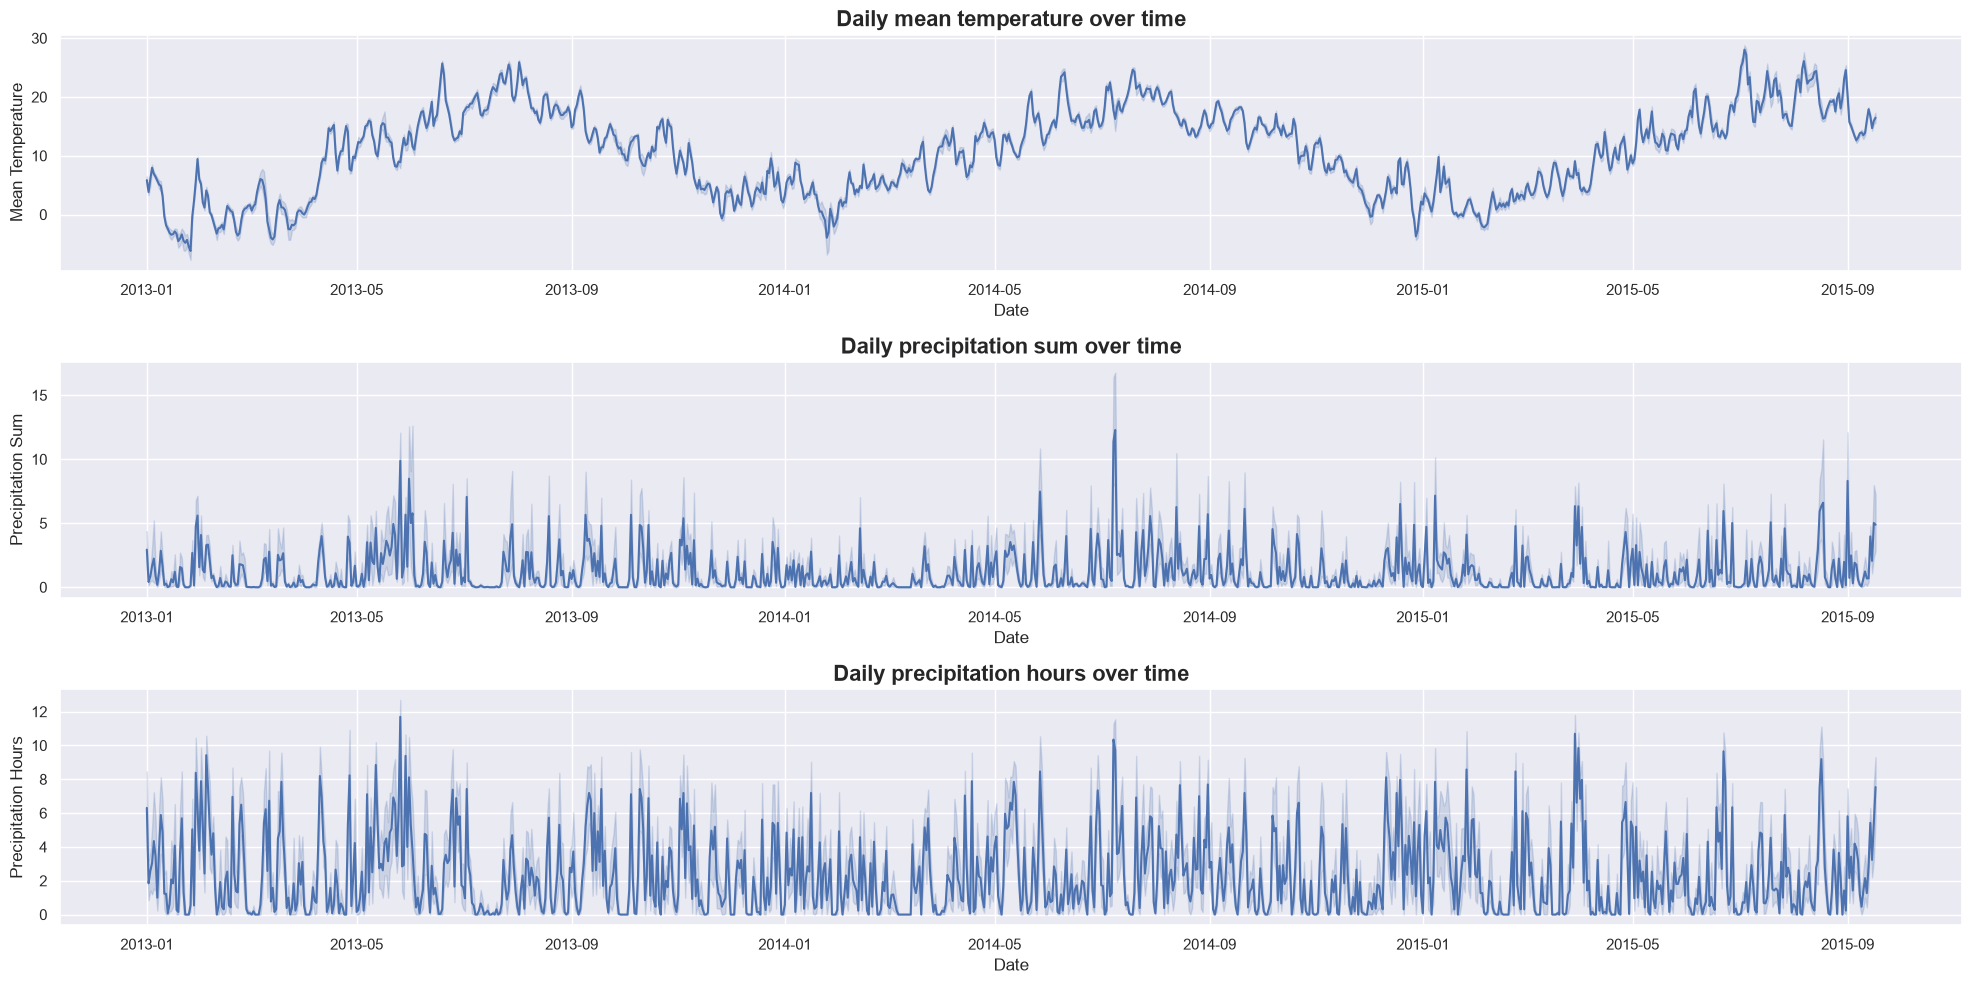

In [41]:
# mean temperature and precipiation sum over time (daily)

plt.figure(figsize=(20, 10))

# plot for mean temperature
plt.subplot(3, 1, 1)
sns.lineplot(weather_df, x="date", y="temperature_2m_mean")
plt.title("Daily mean temperature over time", fontsize = 16, fontweight = "bold")
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Mean Temperature", fontsize = 12)

# plot for precipitation sum
plt.subplot(3, 1, 2)
sns.lineplot(weather_df, x="date", y="precipitation_sum")
plt.title("Daily precipitation sum over time", fontsize = 16, fontweight = "bold")
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Precipitation Sum", fontsize = 12)
plt.tight_layout()

# plot for precipitation hour
plt.subplot(3, 1, 3)
sns.lineplot(weather_df, x="date", y="precipitation_hours")
plt.title("Daily precipitation hours over time", fontsize = 16, fontweight = "bold")
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Precipitation Hours", fontsize = 12)
plt.tight_layout()

plt.show()

In [42]:
### FEATURE ENGINEERING FOR TEMPERATURE AND PRECIPITATION VARIABLES ###

# temperature mean (cold days)

weather_df["is_cold_day"] = weather_df["temperature_2m_mean"] < 0


# temperature max (hot days) 

weather_df["is_warm_day"] = weather_df["temperature_2m_max"] > 25

weather_df["is_hot_day"] = weather_df["temperature_2m_max"] > 30


# precipitation sum (high - rainy & snowy days)

weather_df["is_rainy_sum"] = weather_df["precipitation_sum"] > 5

# precipitation hours (long - rainy & snowy days)

weather_df["is_rainy_time"] = weather_df["precipitation_hours"] > 5

weather_df["is_rainy_time2"] = weather_df["precipitation_hours"] > 10

In [43]:
weather_df

,date,land,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,2013-01-01,BE/BB,7.45,5.90,6.55,0.70,3.00,False,False,False,False,False,False
1,2013-01-01,BW,7.80,3.40,5.70,1.30,6.00,False,False,False,False,True,False
2,2013-01-01,BY,5.80,-3.10,1.00,0.00,0.00,False,False,False,False,False,False
3,2013-01-01,HB/NI,9.40,3.65,6.90,6.25,11.00,False,False,False,True,True,True
4,2013-01-01,HE,7.70,4.10,6.20,2.60,9.00,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,2015-09-17,SH/MV,18.75,14.30,16.85,1.55,5.00,False,False,False,False,False,False
12866,2015-09-17,SL,16.60,12.10,14.50,9.10,12.00,False,False,False,True,True,True
12867,2015-09-17,SN,26.70,14.60,19.70,2.10,3.00,False,True,False,False,False,False
12868,2015-09-17,ST,20.90,14.80,17.30,3.00,7.00,False,False,False,False,True,False


In [44]:
weather_bool_cols = ["is_cold_day", "is_warm_day", "is_hot_day",
                     "is_rainy_sum", "is_rainy_time", "is_rainy_time2"]

for col in weather_bool_cols:
    weather_df[col] = weather_df[col].astype(int)

weather_df.head()

,date,land,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,2013-01-01,BE/BB,7.45,5.90,6.55,0.70,3.00,0,0,0,0,0,0
1,2013-01-01,BW,7.80,3.40,5.70,1.30,6.00,0,0,0,0,1,0
2,2013-01-01,BY,5.80,-3.10,1.00,0.00,0.00,0,0,0,0,0,0
3,2013-01-01,HB/NI,9.40,3.65,6.90,6.25,11.00,0,0,0,1,1,1
4,2013-01-01,HE,7.70,4.10,6.20,2.60,9.00,0,0,0,0,1,0


In [45]:
weather_df.columns.tolist()

['date',
 'land',
 'temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'precipitation_sum',
 'precipitation_hours',
 'is_cold_day',
 'is_warm_day',
 'is_hot_day',
 'is_rainy_sum',
 'is_rainy_time',
 'is_rainy_time2']

In [46]:
cols_to_save =[
 'date',
 'land',
 'is_cold_day',
 'is_warm_day',
 'is_hot_day',
 'is_rainy_sum',
 'is_rainy_time',
 'is_rainy_time2'
]

weather_df_final = weather_df[cols_to_save]

In [47]:
# weather_df_final.to_csv("weather_data_processed.csv", index = False)

## 04. Merging data on German federal states & weather conditions with Rossmann processed dataset

In [48]:
# loading all datasets

rossmann_data = pd.read_csv("../01_data/02_processed/01_Rossmann/rossmann_data_processed_final.csv")
states_data = pd.read_csv("../01_data/02_processed/02_external/state_per_store_assignment.csv")
weather_data = pd.read_csv("../01_data/02_processed/02_external/weather_data_processed.csv")

In [49]:
rossmann_data.head(3)

,Store,Date,Sales,Sales_log,StoreType,Assortment,Promo,Promo_Start,Promo_Start_Tomorrow,Promo_End,Promo_End_Yesterday,Promo_Duration_Days,Promo2_Active,Promo2_Duration_Days,Promo2Renewal,Competition_Exists,Competition_Existence_Days,Competition_Existence_Days_clip,CompetitionDistance_v2,DayOfWeek,week_of_month,is_month_begin,is_month_end,month_of_year,quarter_of_year,open_closed_tomorrow,open_closed_yesterday,Hol_Any,Hol_Christmas_1w,Hol_Christmas_2w,Hol_Christmas_3w,Hol_Easter_1w,Hol_Easter_2w,Hol_Easter_3w,Hol_Special_Event,SchoolHoliday,SchoolHoliday_Only,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_28,Sales_rolling_mean_7,Sales_rolling_mean_14,Sales_rolling_mean_28,Sales_log_lag_1,Sales_log_lag_7,Sales_log_lag_14,Sales_log_lag_28,Sales_log_rolling_mean_7,Sales_log_rolling_mean_14,Sales_log_rolling_mean_28
0,1,2013-01-02,5530,8.62,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1584.00,1584.00,1270.00,Wednesday,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,8.37,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1585.00,1585.00,1270.00,Thursday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,5530.00,NaN,NaN,NaN,NaN,NaN,NaN,8.62,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-01-04,4486,8.41,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1586.00,1586.00,1270.00,Friday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4327.00,NaN,NaN,NaN,NaN,NaN,NaN,8.37,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
states_data.head(3)

,Store,assigned_land
0,1,HE
1,2,TH
2,3,NW


In [51]:
weather_data.head(3)

,date,land,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,2013-01-01,BE/BB,0,0,0,0,0,0
1,2013-01-01,BW,0,0,0,0,1,0
2,2013-01-01,BY,0,0,0,0,0,0


In [52]:
# merging datasets

df = rossmann_data.merge(states_data, on ="Store", how="left")
df = df.merge(weather_data, left_on = ["assigned_land", "Date"], right_on = ["land", "date"], how="left")
df = df.drop(columns=["land", "date"])
df.head()

,Store,Date,Sales,Sales_log,StoreType,Assortment,Promo,Promo_Start,Promo_Start_Tomorrow,Promo_End,Promo_End_Yesterday,Promo_Duration_Days,Promo2_Active,Promo2_Duration_Days,Promo2Renewal,Competition_Exists,Competition_Existence_Days,Competition_Existence_Days_clip,CompetitionDistance_v2,DayOfWeek,week_of_month,is_month_begin,is_month_end,month_of_year,quarter_of_year,open_closed_tomorrow,open_closed_yesterday,Hol_Any,Hol_Christmas_1w,Hol_Christmas_2w,Hol_Christmas_3w,Hol_Easter_1w,Hol_Easter_2w,Hol_Easter_3w,Hol_Special_Event,SchoolHoliday,SchoolHoliday_Only,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_28,Sales_rolling_mean_7,Sales_rolling_mean_14,Sales_rolling_mean_28,Sales_log_lag_1,Sales_log_lag_7,Sales_log_lag_14,Sales_log_lag_28,Sales_log_rolling_mean_7,Sales_log_rolling_mean_14,Sales_log_rolling_mean_28,assigned_land,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,1,2013-01-02,5530,8.62,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1584.00,1584.00,1270.00,Wednesday,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
1,1,2013-01-03,4327,8.37,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1585.00,1585.00,1270.00,Thursday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,5530.00,NaN,NaN,NaN,NaN,NaN,NaN,8.62,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
2,1,2013-01-04,4486,8.41,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1586.00,1586.00,1270.00,Friday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4327.00,NaN,NaN,NaN,NaN,NaN,NaN,8.37,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
3,1,2013-01-05,4997,8.52,type_C,basic,0,0,1,0,0,NaN,0,NaN,0,1,1587.00,1587.00,1270.00,Saturday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,4486.00,NaN,NaN,NaN,NaN,NaN,NaN,8.41,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
4,1,2013-01-07,7176,8.88,type_C,basic,1,1,0,0,0,1.00,0,NaN,0,1,1589.00,1589.00,1270.00,Monday,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4997.00,NaN,NaN,NaN,NaN,NaN,NaN,8.52,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0


 ## 05. Additional EDA: Analyzing sales levels depending on store location (federal state)

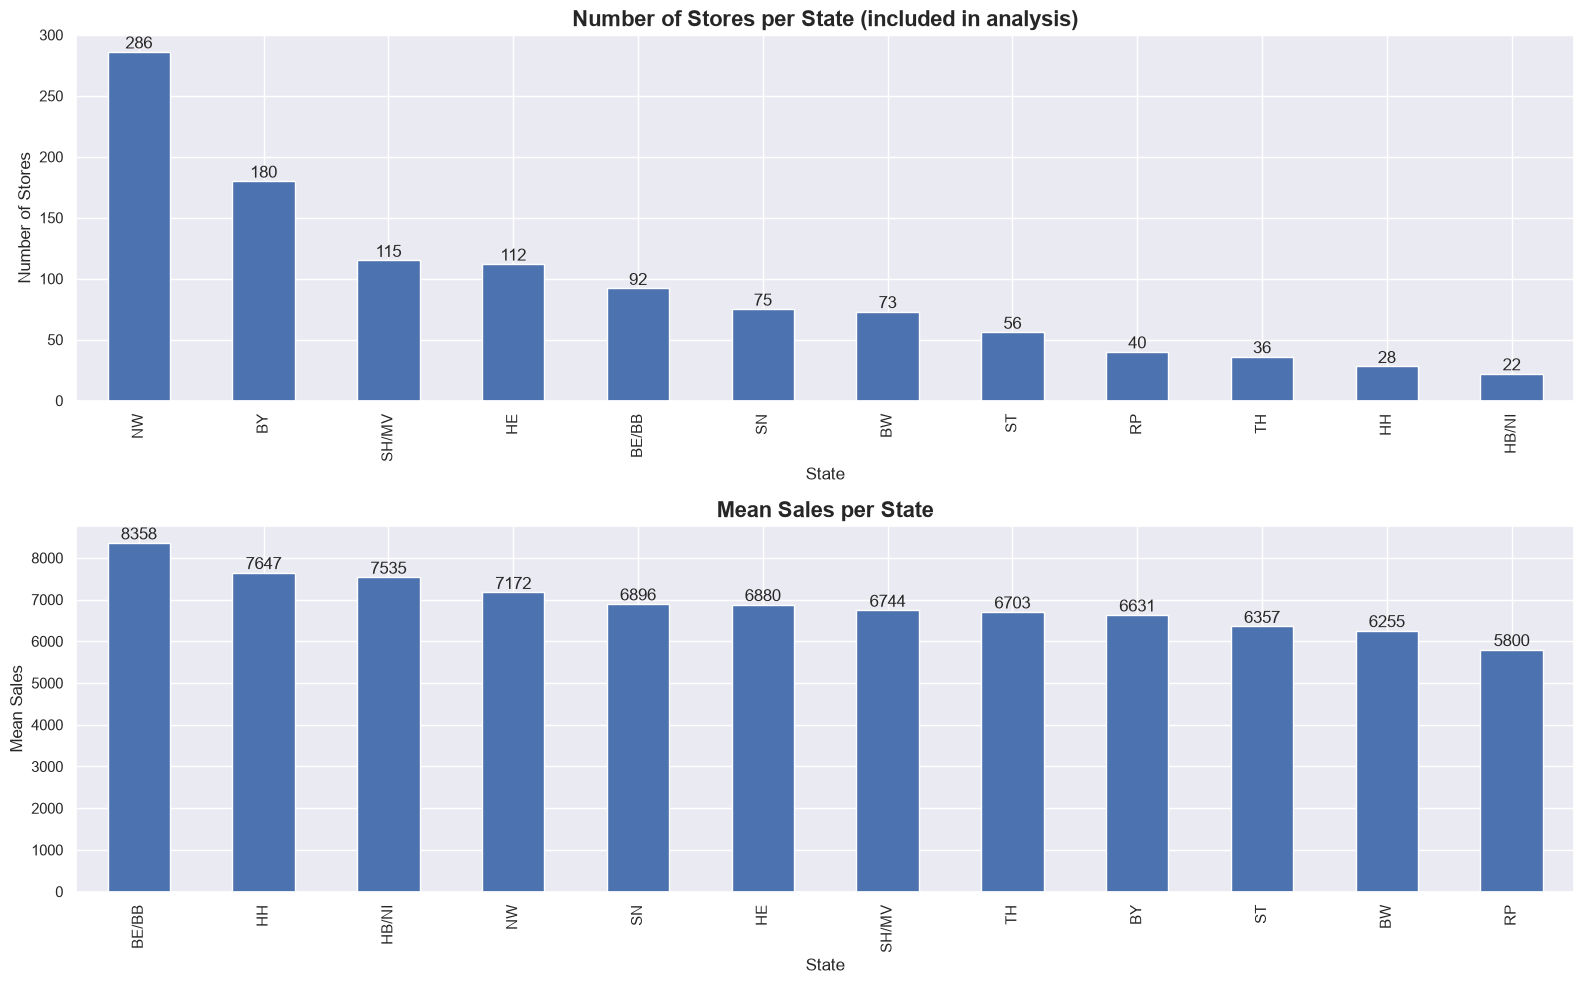

In [53]:
### Sales vs German Federal State ###

# Number of stores per German Federal State & Mean sales per German Federal State

num_of_stores_per_state = df.groupby("assigned_land")["Store"].nunique().sort_values(ascending=False)
mean_sales_per_state = df.groupby("assigned_land")["Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 10))

# plot for number of stores per state
ax1 = plt.subplot(2, 1, 1)
num_of_stores_per_state.plot(kind="bar", ax = ax1)
ax1.set_title("Number of Stores per State (included in analysis)", fontsize=16, fontweight="bold")
ax1.set_xlabel("State", fontsize=12)
ax1.set_ylabel("Number of Stores", fontsize=12)
ax1.bar_label(ax1.containers[0], fmt='%.0f')


# plot for mean sales per state
ax2 = plt.subplot(2, 1, 2)
mean_sales_per_state.plot(kind="bar", ax = ax2)
ax2.set_title("Mean Sales per State", fontsize=16, fontweight="bold")
ax2.set_xlabel("State", fontsize=12)
ax2.set_ylabel("Mean Sales", fontsize=12)
ax2.bar_label(ax2.containers[0], fmt='%.0f')
plt.tight_layout()

plt.show()

In [54]:
# StoreType vs State

pd.crosstab(df["assigned_land"], df["StoreType"], normalize="index")

StoreType,type_A,type_B,type_C,type_D
assigned_land,,,,
BE/BB,0.58,0.06,0.24,0.12
BW,0.45,0.03,0.18,0.34
BY,0.47,0.01,0.08,0.45
HB/NI,0.54,0.05,0.23,0.18
HE,0.35,0.03,0.11,0.51
HH,0.60,0.04,0.28,0.07
NW,0.66,0.01,0.08,0.25
RP,0.30,0.03,0.07,0.60
SH/MV,0.65,0.00,0.10,0.25


In [55]:
# Assortment vs State

pd.crosstab(df["assigned_land"], df["Assortment"], normalize="index")

Assortment,basic,extended,extra
assigned_land,,,
BE/BB,0.73,0.27,0.00
BW,0.42,0.54,0.03
BY,0.64,0.36,0.01
HB/NI,0.63,0.37,0.00
HE,0.51,0.46,0.03
HH,0.47,0.53,0.00
NW,0.55,0.44,0.01
RP,0.52,0.45,0.03
SH/MV,0.12,0.88,0.00


In [56]:
# Promo intensity vs State

df.groupby("assigned_land")["Promo"].mean()

assigned_land
BE/BB   0.45
BW      0.45
BY      0.44
HB/NI   0.45
HE      0.45
HH      0.45
NW      0.45
RP      0.45
SH/MV   0.44
SN      0.45
ST      0.45
TH      0.45
Name: Promo, dtype: float64

### **Observations:**

- Considerable **differences in average sales levels** can be observed **between federal states**. For example, stores assigned to the `Berlin & Brandenburg` region (`BE/BB`) achieve noticeably higher mean sales than stores located in several other regions like `Baden-Württemberg` (`BW`) or `Rhineland-Palatinate` (`RP`). In general, it is noticeable that federal states in the **Western and Northern parts** of Germany achieved on average **relatively higher sales results** than the stores in the Southern and South-eastern parts.

- The dataset is not evenly distributed across regions. `North Rhine-Westphalia` (`NW`) and `Bavaria` (`BY`) contain the **largest number of stores**, while some regions (e.g. `HB/NI`) are represented by only a small number of locations.

- The distribution of store types (`StoreType`) and assortment strategies (`Assortment`) varies across federal states. Some regions are dominated by a single store type, whereas others exhibit a more diversified store structure.

### **Key takeaways**

- Regional differences appear to be associated not only with geography itself, but also with differences in store characteristics and assortment strategies.

- Nevertheless, the observed variation in sales levels suggests that regional information may contain additional predictive value beyond the variables available in the original Rossmann dataset.

- Therefore, the reconstructed federal-state assignment (assigned_land) **will be considered as a potential contextual feature during the modeling stage**.

## 06. Additional EDA: Analyzing sales levels depending on weather conditions 

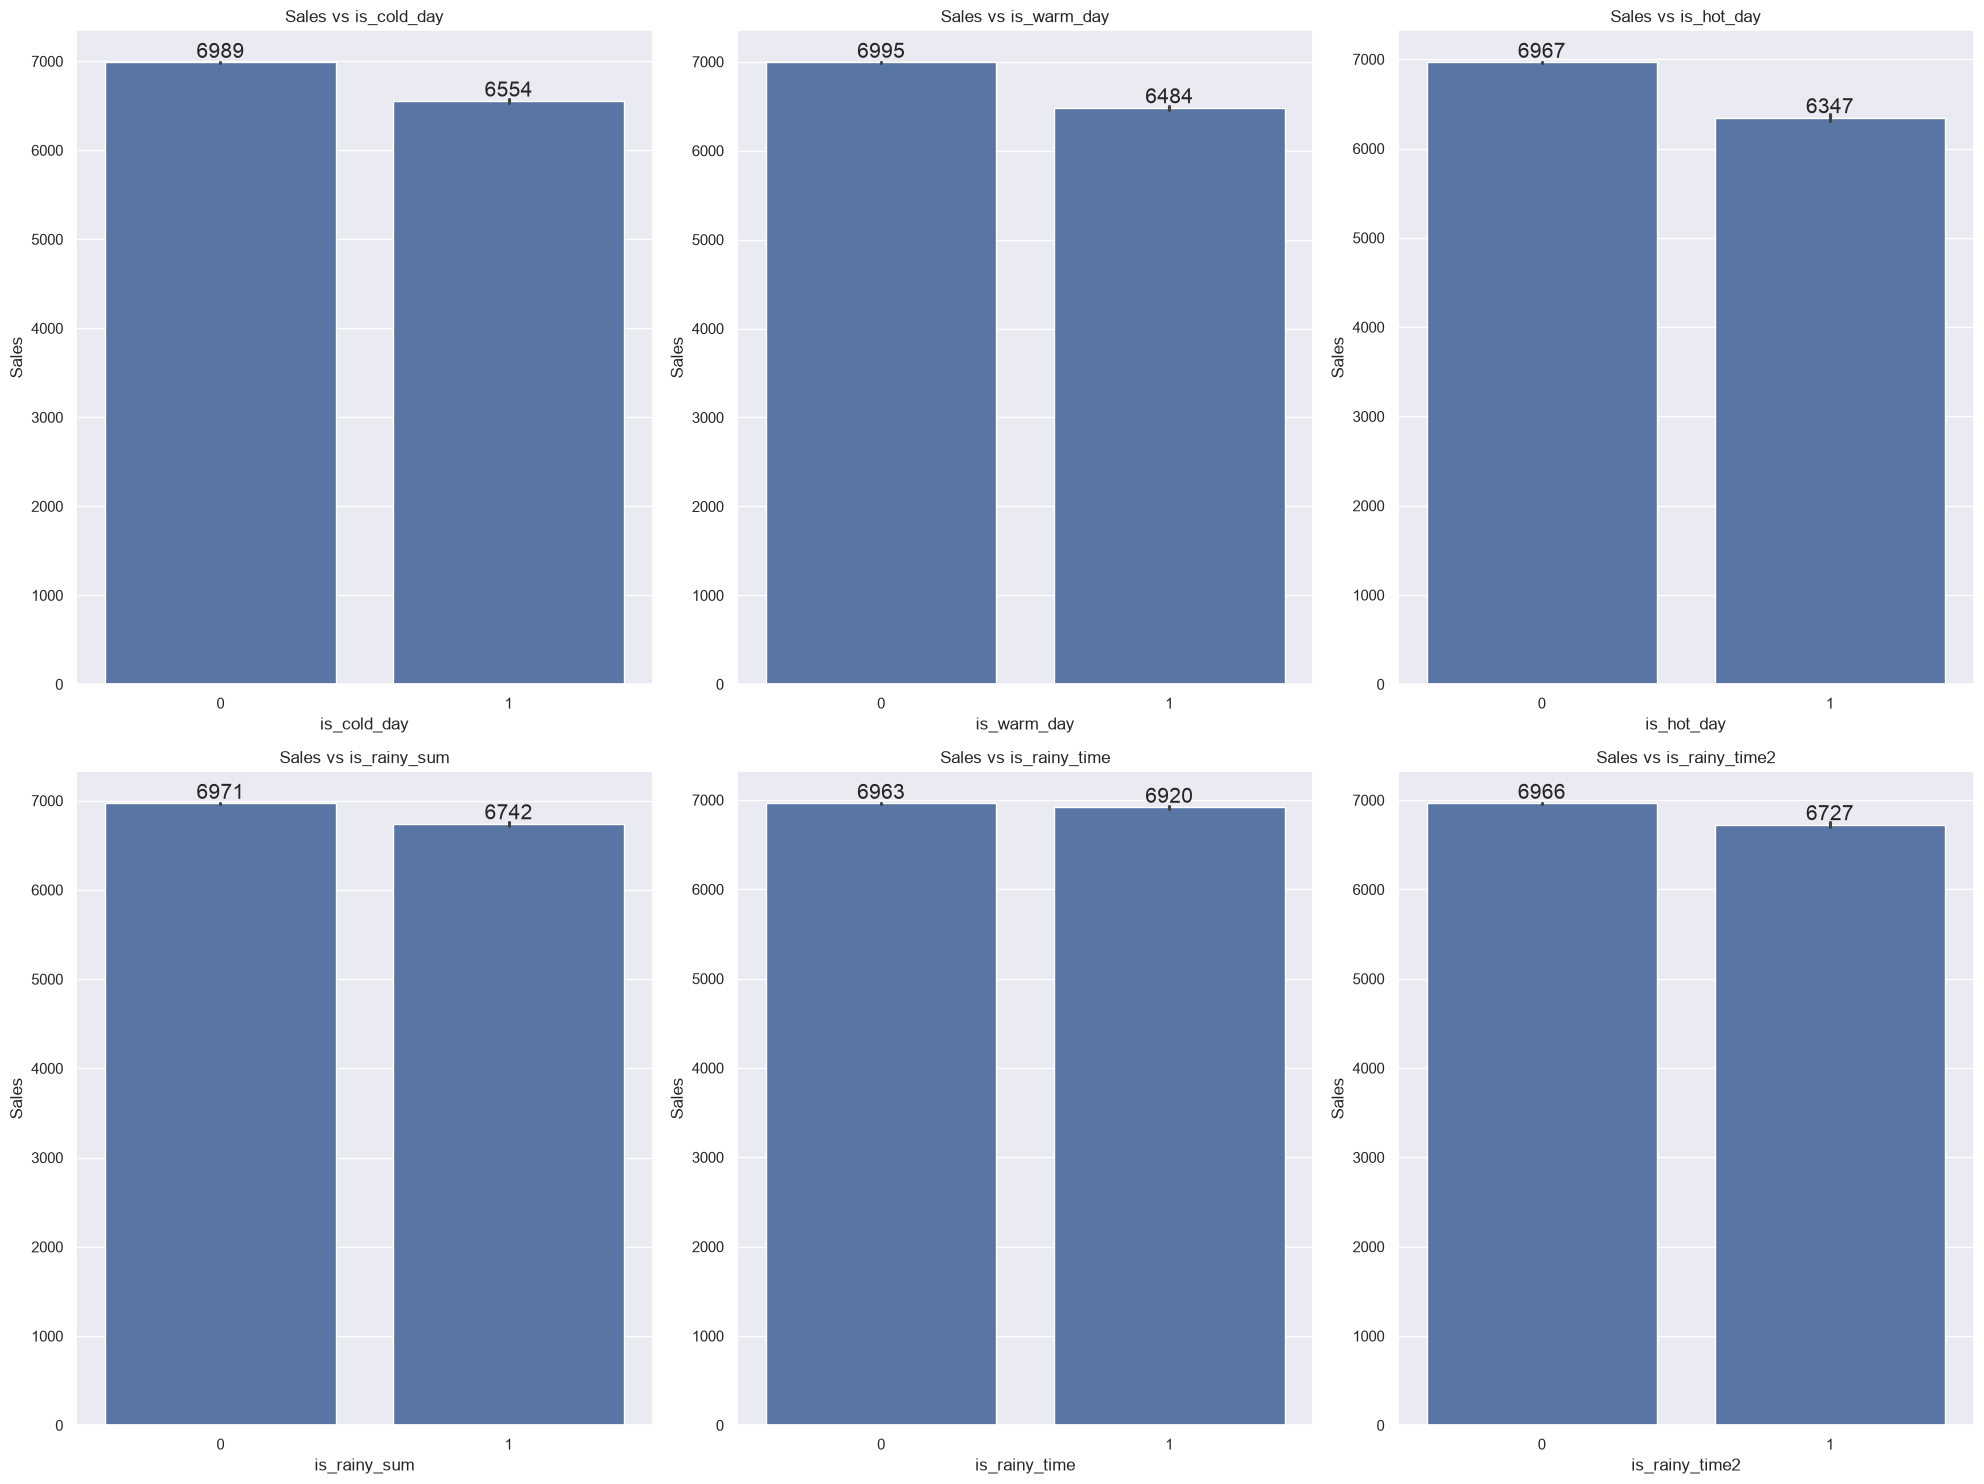

In [57]:
### Sales vs Weather-related features ###

plt.figure(figsize=(20, 15))

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.0f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=15
        )


# Sales vs is_cold_day
ax1 = plt.subplot(2, 3, 1)
sns.barplot(data=df, x="is_cold_day", y="Sales", ax=ax1)
ax1.set_title("Sales vs is_cold_day")
add_labels(ax1)

# Sales vs is_warm_day
ax2 = plt.subplot(2, 3, 2)
sns.barplot(data=df, x="is_warm_day", y="Sales", ax=ax2)
ax2.set_title("Sales vs is_warm_day")
add_labels(ax2)

# Sales vs is_hot_day
ax3 = plt.subplot(2, 3, 3)
sns.barplot(data=df, x="is_hot_day", y="Sales", ax=ax3)
ax3.set_title("Sales vs is_hot_day")
add_labels(ax3)

# Sales vs is_rainy_sum
ax4 = plt.subplot(2, 3, 4)
sns.barplot(data=df, x="is_rainy_sum", y="Sales", ax=ax4)
ax4.set_title("Sales vs is_rainy_sum")
add_labels(ax4)

# Sales vs is_rainy_time
ax5 = plt.subplot(2, 3, 5)
sns.barplot(data=df, x="is_rainy_time", y="Sales", ax=ax5)
ax5.set_title("Sales vs is_rainy_time")
add_labels(ax5)

# Sales vs is_rainy_time2
ax6 = plt.subplot(2, 3, 6)
sns.barplot(data=df, x="is_rainy_time2", y="Sales", ax=ax6)
ax6.set_title("Sales vs is_rainy_time2")
add_labels(ax6)

plt.tight_layout()
plt.show()

In [58]:
# correlations between weather features and Sales_log (Pearson)

weather_features = [
    "is_cold_day",
    "is_warm_day",
    "is_hot_day",
    "is_rainy_sum",
    "is_rainy_time",
    "is_rainy_time2"
]

weather_corr = (
    df[weather_features + ["Sales_log"]]
    .corr(method="pearson")
    [["Sales_log"]]
    .drop("Sales_log")
    .sort_values("Sales_log", ascending=False)
)

weather_corr

,Sales_log
is_rainy_time,-0.01
is_rainy_time2,-0.02
is_rainy_sum,-0.02
is_hot_day,-0.03
is_warm_day,-0.04
is_cold_day,-0.04


### **Observations & Conclusion:**

- Weather conditions may influence customer behavior and shopping activity. Therefore, external weather data were incorporated to evaluate whether temperature and precipitation provide additional explanatory power beyond the variables available in the original Rossmann dataset.

- Only **minor differences in average sales levels** can be observed between **cold, warm, hot, and rainy days**. The **linear correlations** are also **week**, suggesting a limited direct relationship between daily weather conditions and sales performance. The observed effects appear substantially weaker than those associated with promotions, holidays, or store characteristics.

- Although weather features were considered as potential predictors, **exploratory analysis suggests that their relationship with sales is relatively weak**. Consistent with these findings, weather-related features showed low importance during model development and - *spoiler* - were ultimately excluded from the final forecasting model.


## 07. Saving the final dataset for modeling

In [59]:

# df.to_csv("rossmann_dataset_for_modeling_final.csv", index = False)

In [ ]:
# import fastparquet
# df = pd.read_csv("../01_data/03_modeling/rossmann_dataset_for_modeling_final.csv")
# df.to_parquet("../01_data/03_modeling/rossmann_dataset_for_modeling_final.parquet", index = False, engine="fastparquet")